# Effect of pre-computing CNN embeddings on training speed for CNN based classfiers: 

## Problem Statement

A common approach to transfer learning of CNN classifiers is to freeze the CNN component and train only the MLP classifier head. There are two approaches possible to training the MLP classifier head. We can either perform inference on the entire CNN+MLP architecture and update only the MLP classifier, or we can precompute the embeddings of the CNN component and perform inference and training on only the MLP classifier.

Because the CNN component is frozen, the **same embedding  is computed for every image every epoch** - disregarding the image augmentation for now. This means that we waste compute every time we do a forward pass through the CNN component of ResNet18.

We will compare the effects of the two approach on training speed and validation set accuracy.


## Two Approaches Being Compared

| Approach | Script | What trains |
|---|---|---|
| **CNN + MLP classifier** | `src/train.py` | Frozen CNN component → MLP head (re-runs CNN component every epoch with live augmentation) |
| **MLP-classifier-only** | `src/train_head.py` | MLP head on fixed 512-d embedding extracted once from CNN component. To include image augmentation, we created 5 augmented copies of the original training dataset and extrated their embeddings.|

The key difference: CNN+MLP classifier training re-runs the CNN component every epoch (live augmentation), while MLP-classifier-only computes the CNN component embeddings once and trains the MLP-classifier on those embeddings.



## Metrics We Care About

**Performance**
- **Val accuracy** (primary)
    - the metric that tells you if the approach actually works. We will compare the end-to-end inference val accuracy of the weights trained from the two methods. We will create the same Resnet18 architecture, and load the weights from both training methods, and compare their performance end to end-- raw image to classification.

**Efficiency**
- **Wall-clock time per epoch** 
    - MLP-classifier only training method will likely have a shorter wall-clock time per epoch. CNN forward pass is skiped during its epoch as it is computed upfront.

- **CNN embedding extraction time for MLP-classifier-only training** 
    - This is the time it takes to compute CNN embeddings of 5 copies of augmentation applied training dataset and 1 copy of validation dataset.
    - CNN embedding extraction is repeated every epoch for the CNN+MLP classifer training and thus its time is implicit in its wall-clock time per epoch.

- **Total training time**
    - CNN+MLP classifier - (wall-clock × epochs to convergence)
    - MLP-classifier-only — (wall-clock × epochs to convergence) + CNN embedding extraction time for MLP-classifier-only training

- **Cost** 
    - SageMaker instance-hours × $/hr
    - the MLP-only job should be dramatically cheaper since it can use a CPU instance or smaller GPU


**The key question this experiment answers:** how much faster is training when you precompute the CNN embeddings and only train the MLP-classifier component? And is there a performance degradation in this approach? 


In [ ]:
from IPython.display import Image
Image('../docs/diagrams/transfer_learning_approaches.png')

## 2 — Setup

In [25]:
import sys
import os
from dotenv import load_dotenv
from pathlib import Path


# Add src/ to path so we can import model.py from the notebook
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))
repo_root = Path().resolve().parent
load_dotenv(repo_root / ".env")   # load .env from repo root

# If running from repo root: sys.path.insert(0, 'src')
load_dotenv()
import torch
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

WANDB_PROJECT = "hw2p2-ablations"
WANDB_ENTITY  = "kyungin"   # fill in your WandB username or team name

FULL_PIPELINE_RUN_ID =  "resnet-face-20260406171208-jw7y5f-algo-1"  # 25-epoch full pipeline run ID from WandB
MLP_ONLY_RUN_ID      = "resnet-head-MLP-20260407153431-v5in5e-algo-1"   # Head B stage 2 MLP-only run ID from WandB

if torch.cuda.is_available():
    device = torch.device('cuda')                                                                                  
elif torch.backends.mps.is_available():
    device = torch.device('mps')                                                                                   
else:                                                 
    device = torch.device('cpu')
print(f"Device: {device}")

Device: mps


## 3 — End-to-End Validation: ResNet18 with weights from CNN+MLP training vs MLP-only training

`train_head.py` trains and evaluates the MLP head entirely on pre-extracted 512-d embeddings (`val.pt`). Those embeddings were produced by the frozen backbone, so evaluating the head on those features is mathematically equivalent to running the full pipeline on raw images. Weights of both approaches are evaluated on raw val images through the same architecture.

In [74]:
# Step 1 — Instantiate two fresh ResNet18 instances with the same architecture
from model import ResNet18, MLPHead, HEAD_CONFIGS, freeze_backbone, load_backbone_only, topk_accuracy

HEAD_CONFIG = 'B'   # must match the MLP-only run
NUM_CLASSES = 7001

head_cfg = HEAD_CONFIGS[HEAD_CONFIG]
# MLP-classifier-only model (same architecture as full pipeline, but will load weights from different training method)
head = MLPHead(in_features=512, num_classes=NUM_CLASSES, **head_cfg)
model_MLP_ONLY = ResNet18(num_classes=NUM_CLASSES, head=head).to(device)
# CNN_MLP model
head = MLPHead(in_features=512, num_classes=NUM_CLASSES, **head_cfg)
model_CNN_MLP = ResNet18(num_classes=NUM_CLASSES, head=head).to(device)


In [77]:
# Step 2 — Load weights from each training method into the appropriate model

# MLP-only model: load the backbone weights from the baseline ResNet18 checkpoint, then load the MLP head weights from the MLP-only checkpoint.
# This replicates the exact backbone state the MLP head saw during feature extraction.
BASELINE_CKPT = "../checkpoints/checkpoint.pth"   # path to the baseline ResNet18 checkpoint (.pt file)
load_backbone_only(BASELINE_CKPT, model_MLP_ONLY, device)

# Load the trained MLP head weights from the best checkpoint
MLP_CKPT = "../model/mlp_head/model.pt"   
mlp_ckpt = torch.load(MLP_CKPT, map_location=device, weights_only=True)
head_state = mlp_ckpt['model_state']
# Strip _orig_mod. prefix added by torch.compile
head_state = {k.replace('_orig_mod.', ''): v for k, v in head_state.items()}
model_MLP_ONLY.head.load_state_dict(head_state)
print("MLP head weights loaded.")


# CNN+MLP model: load the full model weights from the full pipeline checkpoint.
FULL_PIPELINE_CKPT = "../model/full_pipeline/model.pt"   # path to best.pt from the full-pipeline run
full_ckpt = torch.load(FULL_PIPELINE_CKPT, map_location=device, weights_only=True)
state = full_ckpt['model_state']   # key used by src/train.py
state = {k.replace('_orig_mod.', ''): v for k, v in state.items()}
model_CNN_MLP.load_state_dict(state)
print("CNN_MLP head weights loaded.")

Backbone loaded. New head randomly initialized (7 keys.
MLP head weights loaded.
CNN_MLP head weights loaded.


In [9]:
# Step 4 — Build a raw-image val DataLoader
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

VAL_DIR = "../data/dev"   # directory of raw val images

val_transforms = T.Compose([
    T.ToTensor()
])
val_dataset = ImageFolder(VAL_DIR, transform=val_transforms)
val_loader  = DataLoader(val_dataset, batch_size=256, shuffle=False,
                         num_workers=4, pin_memory=False, prefetch_factor=2, persistent_workers=True)
print(f"Val dataset: {len(val_dataset):,} samples")

Val dataset: 35,005 samples


In [78]:
# Step 5 — Evaluate MLP-classifier-only model on raw val images
model_MLP_ONLY.eval()
running_top1, running_top5, n = 0.0, 0.0, 0

with torch.inference_mode():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model_MLP_ONLY(images)
        top1, top5 = topk_accuracy(logits, labels, topk=(1, 5))
        bs = images.size(0)
        running_top1 += top1.item() * bs
        running_top5 += top5.item() * bs
        n += bs

mlp_end_to_end_top1 = running_top1 / n
mlp_end_to_end_top5 = running_top5 / n
print(f"MLP-Only (end-to-end, raw images): top-1={mlp_end_to_end_top1:.2f}%  top-5={mlp_end_to_end_top5:.2f}%")

MLP-Only (end-to-end, raw images): top-1=83.29%  top-5=89.99%


In [79]:
# Step 6 — Evaluate CNN+MLP model on raw val images
model_CNN_MLP.eval()

running_top1, running_top5, n = 0.0, 0.0, 0
with torch.inference_mode():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model_CNN_MLP(images)
        top1, top5 = topk_accuracy(logits, labels, topk=(1, 5))
        bs = images.size(0)
        running_top1 += top1.item() * bs
        running_top5 += top5.item() * bs
        n += bs

full_end_to_end_top1 = running_top1 / n
full_end_to_end_top5 = running_top5 / n
print(f"Full Pipeline (end-to-end, raw images): top-1={full_end_to_end_top1:.2f}%  top-5={full_end_to_end_top5:.2f}%")

Full Pipeline (end-to-end, raw images): top-1=83.71%  top-5=90.12%


In [83]:
# Step 7 — Comparison table (cross-reference with WandB-reported values from Cell 4)
# MLP-Only (WandB) values below are placeholders — replace after running Cell 4
comparison = pd.DataFrame({
    "Metric":            ["Val Top-1 (%)", "Val Top-5 (%)"],
    "CNN+MLP":     [full_end_to_end_top1, full_end_to_end_top5],
    "MLP-Only":    [mlp_end_to_end_top1, mlp_end_to_end_top5],
})
comparison["Diff"] = (
    comparison["CNN+MLP"] - comparison["MLP-Only"]
)
display(comparison)

print("  • Gap < 0.5 pp: MLP-only is viable for hyperparameter sweeps")

,Metric,CNN+MLP,MLP-Only,Diff
0,Val Top-1 (%),83.708042,83.293815,0.414227
1,Val Top-5 (%),90.115698,89.987145,0.128553


  • Gap < 0.5 pp: MLP-only is viable for hyperparameter sweeps


## 4 — Fetch WandB History

In [84]:
api = wandb.Api()

full_run = api.run(f"{WANDB_ENTITY}/{WANDB_PROJECT}/{FULL_PIPELINE_RUN_ID}")
mlp_run  = api.run(f"{WANDB_ENTITY}/{WANDB_PROJECT}/{MLP_ONLY_RUN_ID}")


full_hist = full_run.scan_history()
mlp_hist  = mlp_run.scan_history()


In [85]:

full_df = pd.DataFrame(full_hist).groupby("epoch", as_index=False).first()
mlp_df  = pd.DataFrame(mlp_hist).groupby("epoch", as_index=False).first()

print(f"Full pipeline: {len(full_df)} epochs logged")
print(f"MLP-only:      {len(mlp_df)} epochs logged")
display(full_df.tail(3))
display(mlp_df.tail(3))

Full pipeline: 25 epochs logged
MLP-only:      25 epochs logged


,epoch,val/top5_acc,_step,learning_rate,train/top1_acc,train/top5_acc,val/loss,_timestamp,_runtime,train/loss,val/top1_acc
22,22,90.078560,44,0.008176,86.781174,95.386373,1.057442,1.775527e+09,13327.787834,0.584749,83.328096
23,23,90.084274,46,0.002052,88.434509,96.247679,1.046986,1.775528e+09,13887.197151,0.510343,83.610913
24,24,90.115698,48,0.000000,89.079417,96.532638,1.043610,1.775528e+09,14448.414797,0.479749,83.708042


,epoch,learning_rate,_step,val/loss,train/loss,val/top1_acc,val/top5_acc,train/top1_acc,train/top5_acc,_timestamp,_runtime
22,22,0.008176,44,1.097322,0.687543,82.628196,89.718612,83.831024,94.735181,1.775596e+09,1138.454263
23,23,0.002052,46,1.073687,0.545104,83.253821,90.015712,87.207685,96.375661,1.775596e+09,1187.657567
24,24,0.000000,48,1.071437,0.478751,83.290958,89.984288,88.875018,97.104128,1.775596e+09,1236.836056


## 5 — Accuracy and Training time comparison

The total time for training of MLP head only training is the sum of the time taken to precompute feature of augmented copies of training image, and training the MLP head.

The total time for training of the full pipeline is just the time taken for training the full architecture.

In [86]:
times_for_feature_extraction_train_s = [623, 625, 619, 638, 622] # seconds taken for inference on training image during feature extraction
times_for_feature_extraction_val_s = [25] # seconds taken for inference on validation image during feature extraction
total_time_for_feature_extraction_s = sum(times_for_feature_extraction_train_s) + sum(times_for_feature_extraction_val_s)
total_time_for_feature_extraction_m = total_time_for_feature_extraction_s / 60
print(f"Total time taken for CNN embedding extraction: {total_time_for_feature_extraction_m} minutes")

Total time taken for CNN embedding extraction: 52.53333333333333 minutes


In [88]:
def get_summary_value(run, key, default=None):
    """Safely retrieve a value from a WandB run summary."""
    return run.summary.get(key, default)

full_best_top1  = full_df["val/top1_acc"].max()
full_best_top5  = full_df["val/top5_acc"].max()
full_val_loss   = full_df.loc[full_df["val/top1_acc"].idxmax(), "val/loss"]
full_train_top1 = full_df.loc[full_df["val/top1_acc"].idxmax(), "train/top1_acc"]
full_epochs     = int(full_df["epoch"].max()) + 1
full_train_time_s  = get_summary_value(full_run, "_runtime", 0)
full_train_time_min = full_train_time_s / 60
full_feature_extraction_min = 0
full_total_run_time_min = full_train_time_min + full_feature_extraction_min

mlp_best_top1   = mlp_df["val/top1_acc"].max()
mlp_best_top5   = mlp_df["val/top5_acc"].max()
mlp_val_loss    = mlp_df.loc[mlp_df["val/top1_acc"].idxmax(), "val/loss"]
mlp_train_top1  = mlp_df.loc[mlp_df["val/top1_acc"].idxmax(), "train/top1_acc"]
mlp_epochs      = int(mlp_df["epoch"].max()) + 1
mlp_train_time_s   = get_summary_value(mlp_run, "_runtime", 0)
mlp_train_time_min = mlp_train_time_s / 60
mlp_feature_extraction_min = total_time_for_feature_extraction_m
mlp_total_run_time_min = mlp_train_time_min + mlp_feature_extraction_min

summary = pd.DataFrame({
    "Metric": [
        "Val Top-1 (%)",
        "Val Top-5 (%)",
        "Val Loss",
        "Train Top-1 (%)",
        "Overfit Gap (pp)",
        "Training time (min)",
        "Feature Extraction (min)",
        "Total Runtime = Training time + Feature Extraction (min)",
        "Epochs",
        
    ],
    "CNN+MLP": [
        f"{full_best_top1:.2f}",
        f"{full_best_top5:.2f}",
        f"{full_val_loss:.4f}",
        f"{full_train_top1:.2f}",
        f"{full_train_top1 - full_best_top1:.2f}",
        f"{full_train_time_min:.1f}",
        f"{full_feature_extraction_min:.1f}",
        f"{full_total_run_time_min:.1f}",
        str(full_epochs),
    ],
    "MLP-Only": [
        f"{mlp_best_top1:.2f}",
        f"{mlp_best_top5:.2f}",
        f"{mlp_val_loss:.4f}",
        f"{mlp_train_top1:.2f}",
        f"{mlp_train_top1 - mlp_best_top1:.2f}",
        f"{mlp_train_time_min:.1f}",
        f"{mlp_feature_extraction_min:.1f}",
        f"{mlp_total_run_time_min:.1f}",
        str(mlp_epochs),
    ],
})
summary["Gap (Full − MLP)"] = ""
summary.loc[summary["Metric"] == "Val Top-1 (%)",  "Gap (Full − MLP)"] = f"{full_best_top1 - mlp_best_top1:+.2f} pp"
summary.loc[summary["Metric"] == "Val Top-5 (%)",  "Gap (Full − MLP)"] = f"{full_best_top5 - mlp_best_top5:+.2f} pp"
summary.loc[summary["Metric"] == "Training time (min)", "Gap (Full − MLP)"] = f"{full_train_time_min / max(mlp_train_time_min, 1):.1f}× slower"
summary.loc[summary["Metric"] == "Feature Extraction (min)", "Gap (Full − MLP)"] = f"{full_feature_extraction_min - max(mlp_feature_extraction_min, 1):.1f} min"
summary.loc[summary["Metric"] == "Total Runtime = Training time + Feature Extraction (min)", "Gap (Full − MLP)"] = f"{(full_total_run_time_min) / max((mlp_total_run_time_min), 1):.1f}× slower"
display(summary.set_index("Metric"))

,CNN+MLP,MLP-Only,Gap (Full − MLP)
Metric,,,
Val Top-1 (%),83.71,83.29,+0.42 pp
Val Top-5 (%),90.12,90.02,+0.10 pp
Val Loss,1.0436,1.0714,
Train Top-1 (%),89.08,88.88,
Overfit Gap (pp),5.37,5.58,
Training time (min),241.2,20.6,11.7× slower
Feature Extraction (min),0.0,52.5,-52.5 min
Total Runtime = Training time + Feature Extraction (min),241.2,73.2,3.3× slower
Epochs,25,25,


## 5b — Accuracy & Loss Curves

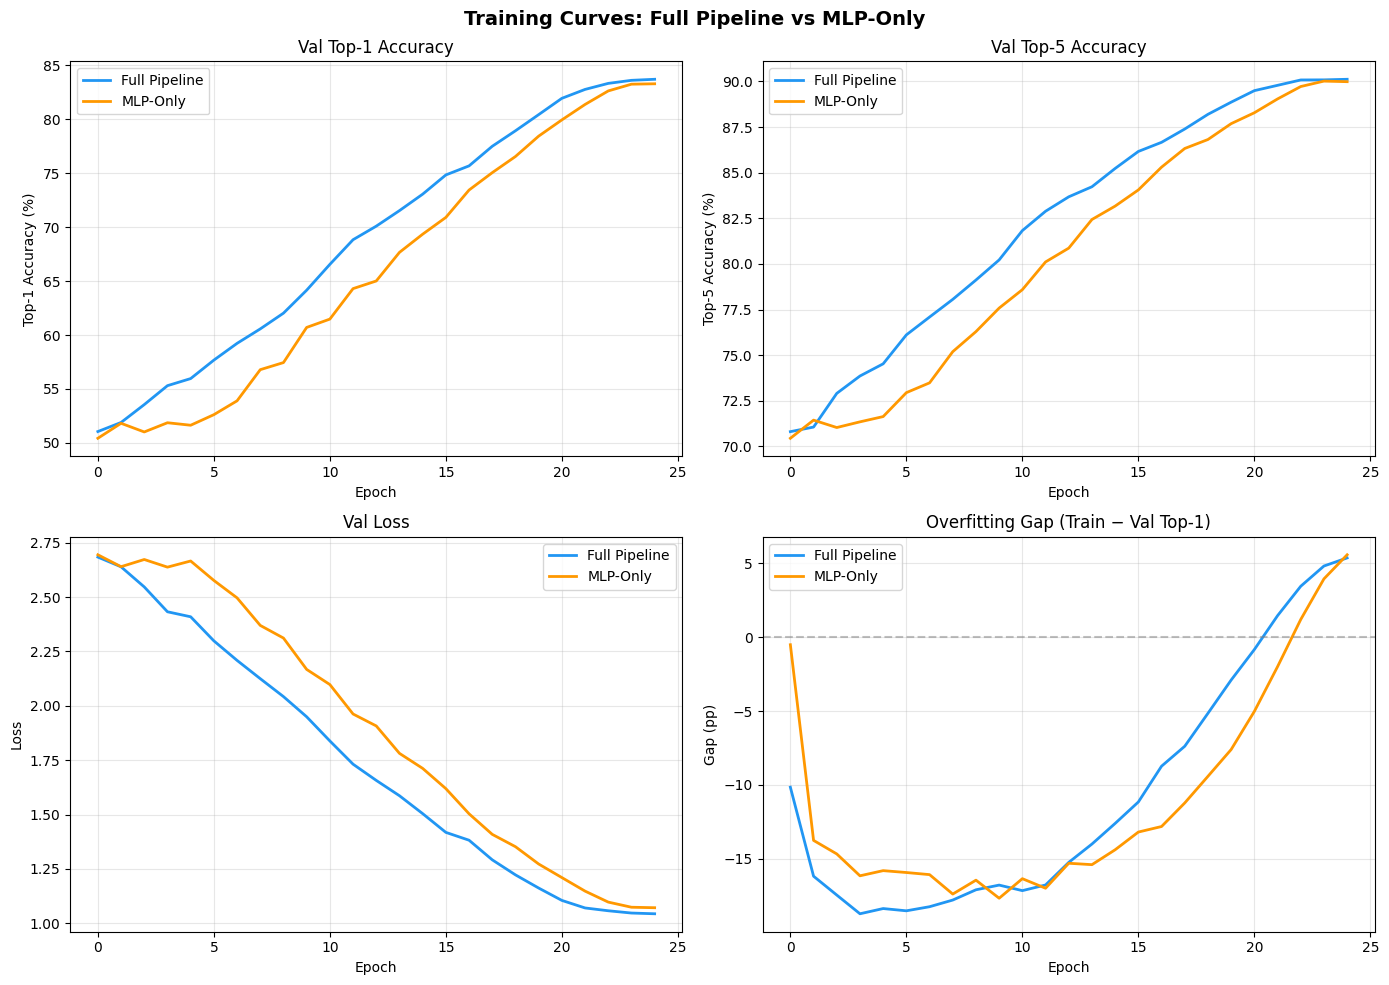

In [89]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Training Curves: Full Pipeline vs MLP-Only", fontsize=14, fontweight='bold')

FULL_COLOR = '#2196F3'   # blue
MLP_COLOR  = '#FF9800'   # orange

# Top-left: Val Top-1 accuracy vs epoch
ax = axes[0, 0]
ax.plot(full_df["epoch"], full_df["val/top1_acc"], color=FULL_COLOR, label="Full Pipeline", linewidth=2)
ax.plot(mlp_df["epoch"],  mlp_df["val/top1_acc"],  color=MLP_COLOR,  label="MLP-Only",      linewidth=2)
ax.set_title("Val Top-1 Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Top-1 Accuracy (%)")
ax.legend()
ax.grid(True, alpha=0.3)

# Top-right: Val Top-5 accuracy vs epoch
ax = axes[0, 1]
ax.plot(full_df["epoch"], full_df["val/top5_acc"], color=FULL_COLOR, label="Full Pipeline", linewidth=2)
ax.plot(mlp_df["epoch"],  mlp_df["val/top5_acc"],  color=MLP_COLOR,  label="MLP-Only",      linewidth=2)
ax.set_title("Val Top-5 Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Top-5 Accuracy (%)")
ax.legend()
ax.grid(True, alpha=0.3)

# Bottom-left: Val loss vs epoch
ax = axes[1, 0]
ax.plot(full_df["epoch"], full_df["val/loss"], color=FULL_COLOR, label="Full Pipeline", linewidth=2)
ax.plot(mlp_df["epoch"],  mlp_df["val/loss"],  color=MLP_COLOR,  label="MLP-Only",      linewidth=2)
ax.set_title("Val Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)

# Bottom-right: Train/val Top-1 gap (overfitting indicator)
ax = axes[1, 1]
full_gap = full_df["train/top1_acc"] - full_df["val/top1_acc"]
mlp_gap  = mlp_df["train/top1_acc"]  - mlp_df["val/top1_acc"]
ax.plot(full_df["epoch"], full_gap, color=FULL_COLOR, label="Full Pipeline", linewidth=2)
ax.plot(mlp_df["epoch"],  mlp_gap,  color=MLP_COLOR,  label="MLP-Only",      linewidth=2)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_title("Overfitting Gap (Train − Val Top-1)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Gap (pp)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig("accuracy_loss_curves.png", dpi=150, bbox_inches='tight')
plt.show()

## 6 — Training Efficiency

Full Pipeline — time/epoch: 579s, total: 241.2 min, cost: $2.959
MLP-Only      — time/epoch: 176s, total: 73.2 min, cost: $0.898
Speedup: 3.3× faster per epoch
Cost reduction: 0.3×


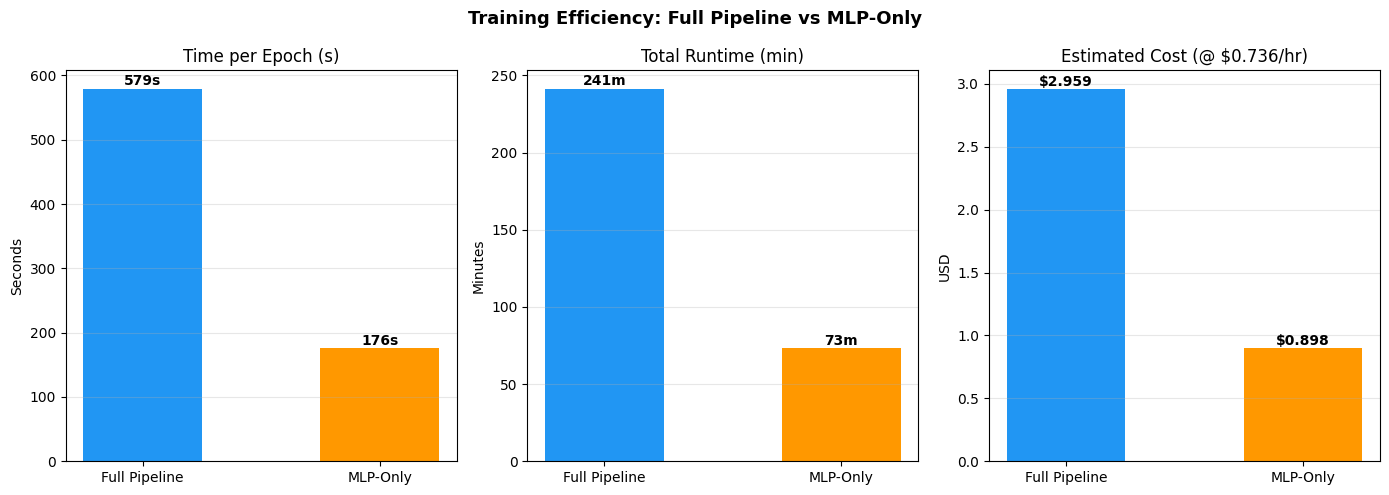

In [90]:
# Wall-clock time per epoch: for the time per epoch, we consider the total runtime divided by the number of epochs. 
# For MLP-only, we also add the feature extraction time to the total runtime before dividing by epochs, since feature extraction is a necessary part of the MLP-only workflow.
full_time_per_epoch = full_total_run_time_min * 60 / max(full_epochs, 1)
mlp_time_per_epoch  = mlp_total_run_time_min * 60 / max(mlp_epochs,  1)

# Cost estimate — ml.g4dn.xlarge on-demand
HOURLY_RATE = 0.736   # $/hr, ml.g4dn.xlarge on-demand
full_cost = (full_total_run_time_min * 60 / 3600) * HOURLY_RATE
mlp_cost  = (mlp_total_run_time_min * 60 / 3600) * HOURLY_RATE

print(f"Full Pipeline — time/epoch: {full_time_per_epoch:.0f}s, total: {full_total_run_time_min:.1f} min, cost: ${full_cost:.3f}")
print(f"MLP-Only      — time/epoch: {mlp_time_per_epoch:.0f}s, total: {mlp_total_run_time_min:.1f} min, cost: ${mlp_cost:.3f}")
print(f"Speedup: {full_time_per_epoch / max(mlp_time_per_epoch, 1):.1f}× faster per epoch")
print(f"Cost reduction: { max(mlp_cost, 0.001)/max(full_cost, 0.001):.1f}×")

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Training Efficiency: Full Pipeline vs MLP-Only", fontsize=13, fontweight='bold')

labels = ["Full Pipeline", "MLP-Only"]
colors = [FULL_COLOR, MLP_COLOR]

# Time per epoch
ax = axes[0]
bars = ax.bar(labels, [full_time_per_epoch, mlp_time_per_epoch], color=colors, width=0.5)
ax.set_title("Time per Epoch (s)")
ax.set_ylabel("Seconds")
for bar, val in zip(bars, [full_time_per_epoch, mlp_time_per_epoch]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.0f}s", ha='center', va='bottom', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Total runtime
ax = axes[1]
bars = ax.bar(labels, [full_total_run_time_min, mlp_total_run_time_min], color=colors, width=0.5)
ax.set_title("Total Runtime (min)")
ax.set_ylabel("Minutes")
for bar, val in zip(bars, [full_total_run_time_min, mlp_total_run_time_min]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.0f}m", ha='center', va='bottom', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Estimated cost
ax = axes[2]
bars = ax.bar(labels, [full_cost, mlp_cost], color=colors, width=0.5)
ax.set_title(f"Estimated Cost (@ ${HOURLY_RATE}/hr)")
ax.set_ylabel("USD")
for bar, val in zip(bars, [full_cost, mlp_cost]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"${val:.3f}", ha='center', va='bottom', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig("efficiency_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## 7 — Conclusion

## Results


In [91]:
display(summary.set_index("Metric"))

,CNN+MLP,MLP-Only,Gap (Full − MLP)
Metric,,,
Val Top-1 (%),83.71,83.29,+0.42 pp
Val Top-5 (%),90.12,90.02,+0.10 pp
Val Loss,1.0436,1.0714,
Train Top-1 (%),89.08,88.88,
Overfit Gap (pp),5.37,5.58,
Training time (min),241.2,20.6,11.7× slower
Feature Extraction (min),0.0,52.5,-52.5 min
Total Runtime = Training time + Feature Extraction (min),241.2,73.2,3.3× slower
Epochs,25,25,


1. The accuracy gap is only 0.42 pp with the CNN+MLP training method with slightly outperforming the MLP-only training method. This may be because the CNN+MLP training method augments its training data randomly for every epoch, while the MLP-only training method uses a training dataset composed of 5 augmentation copies.

2. Even when accounting for the feature extraction time in MLP-only training, the CNN+MLP training method takes 3.3 times longer to train. 

3. Precomputing the CNN embeddings is recommended for training classifier heads to speed up training speed.